# Fixed Mutation Rate Experiment

This notebook evaluates the impact of fixed mutation rates on the performance of a Genetic Algorithm designed to recreate *Girl with a Pearl Earring* using semi-transparent triangles.

The objective is to analyze how different mutation intensities influence convergence speed, exploration capability, image quality, and final RMSE.

Unlike the mutation decay experiment, the mutation rate remains constant throughout the entire evolutionary process.

In [11]:
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
from ga_core import *

## Reproducibility

To ensure consistent and reproducible experiments, a fixed random seed is used for both Python's random module and NumPy.

In [12]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

## Experimental Configuration

The following parameters define the evolutionary setup used in the fixed mutation experiments.

The same population size, number of generations, elitism strategy, and tournament size are maintained across all experiments to isolate the impact of the mutation rate.

In [13]:
POP_SIZE = 30
GENERATIONS = 1000

ELITE_SIZE = 3
TOURNAMENT_SIZE = 5

MUTATION_RATES = [
    0.00,
    0.01,
    0.03,
    0.05,
    0.08,
    0.12
]

## Target Image

The following image represents the optimization target used throughout the experiments.

In [14]:
target = load_target_image("girl_pearl_earing.png")

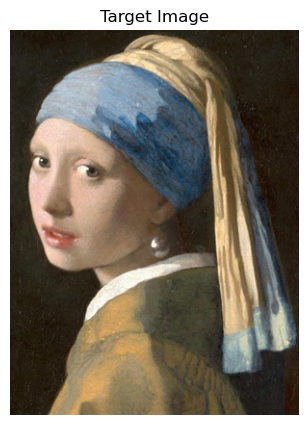

In [15]:
plt.figure(figsize=(4, 5))

plt.imshow(target)
plt.title("Target Image")
plt.axis("off")

plt.show()

## Fixed Mutation Experiment Function

The following function runs the Genetic Algorithm multiple times using different fixed mutation rates.

In this experiment, the mutation rate remains constant during the entire evolutionary process, allowing us to directly evaluate the effect of mutation intensity on convergence and image approximation quality.

In [16]:
def run_mutation_experiment(
    target_img,
    mutation_rates,
    pop_size=POP_SIZE,
    generations=GENERATIONS,
    elite_size=ELITE_SIZE,
    tournament_size=TOURNAMENT_SIZE
):
    """
    Runs the GA with different fixed mutation rates.
    All other GA parameters remain constant.
    """
    results = {}

    for rate in mutation_rates:
        print("=" * 60)
        print(f"Testing fixed mutation rate: {rate}")

        result = evolve_configurable(
            target_img=target_img,
            pop_size=pop_size,
            generations=generations,
            mutation_rate=rate,
            elite_size=elite_size,
            selection_type="tournament",
            tournament_size=tournament_size,
            crossover_type="one_point",
            crossover_rate=1.0,
            use_mutation_decay=False,
            snapshot_generations=[0, generations - 1],
            print_every=100
        )

        best_rend = render_individual(
            result["best_individual"],
            result["background_color"]
        )

        final_rmse = calculate_fitness(best_rend, target_img)

        results[rate] = {
            "best_individual": result["best_individual"],
            "history": result["history"],
            "background_color": result["background_color"],
            "snapshots": result["snapshots"],
            "final_image": best_rend,
            "final_rmse": final_rmse
        }

        print(f"Final RMSE for fixed mutation rate {rate}: {final_rmse:.4f}")

    return results

## Running the Experiments

The Genetic Algorithm is executed several times using different fixed mutation rates ranging from `0.00` to `0.12`.

This range includes:
- no mutation;
- low mutation rates;
- moderate mutation rates;
- aggressive mutation rates.

In [17]:
mutation_results = run_mutation_experiment(
    target_img=target,
    mutation_rates=MUTATION_RATES,
    pop_size=POP_SIZE,
    generations=GENERATIONS,
    elite_size=ELITE_SIZE,
    tournament_size=TOURNAMENT_SIZE
)

Testing fixed mutation rate: 0.0
Generation 00000 | Best RMSE: 56.4600 | Mutation: 0.0000
Generation 00100 | Best RMSE: 53.3038 | Mutation: 0.0000
Generation 00200 | Best RMSE: 53.3038 | Mutation: 0.0000
Generation 00300 | Best RMSE: 53.3038 | Mutation: 0.0000
Generation 00400 | Best RMSE: 53.3038 | Mutation: 0.0000
Generation 00500 | Best RMSE: 53.3038 | Mutation: 0.0000
Generation 00600 | Best RMSE: 53.3038 | Mutation: 0.0000
Generation 00700 | Best RMSE: 53.3038 | Mutation: 0.0000
Generation 00800 | Best RMSE: 53.3038 | Mutation: 0.0000
Generation 00900 | Best RMSE: 53.3038 | Mutation: 0.0000
Generation 00999 | Best RMSE: 53.3038 | Mutation: 0.0000
Final RMSE for fixed mutation rate 0.0: 53.3038
Testing fixed mutation rate: 0.01
Generation 00000 | Best RMSE: 56.3897 | Mutation: 0.0100
Generation 00100 | Best RMSE: 44.7737 | Mutation: 0.0100
Generation 00200 | Best RMSE: 38.2054 | Mutation: 0.0100
Generation 00300 | Best RMSE: 33.4601 | Mutation: 0.0100
Generation 00400 | Best RMSE: 

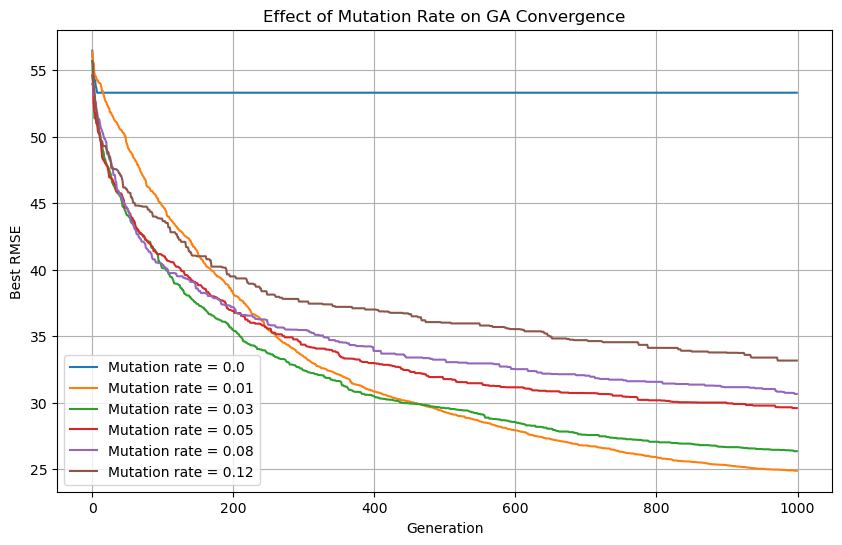

In [18]:
plt.figure(figsize=(10, 6))

for rate, result in mutation_results.items():
    plt.plot(
        result["history"],
        label=f"Mutation rate = {rate}"
    )

plt.title("Effect of Mutation Rate on GA Convergence")
plt.xlabel("Generation")
plt.ylabel("Best RMSE")
plt.legend()
plt.grid(True)
plt.show()

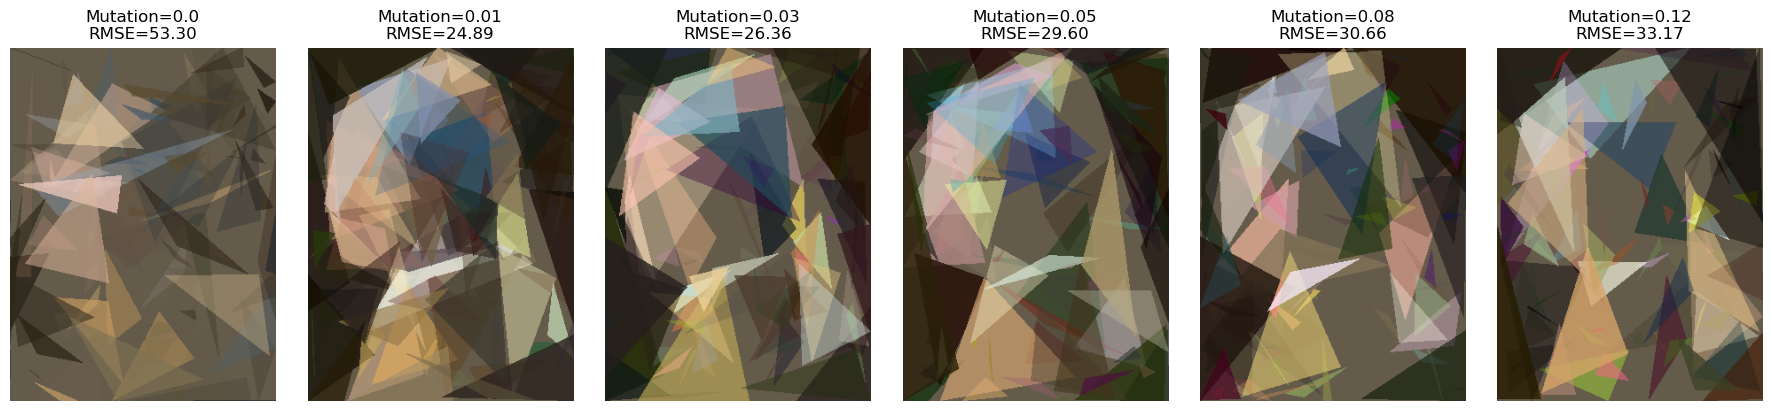

In [19]:
num_results = len(mutation_results)

fig, axes = plt.subplots(
    1,
    num_results,
    figsize=(3 * num_results, 4)
)

if num_results == 1:
    axes = [axes]

for ax, (rate, result) in zip(axes, mutation_results.items()):
    ax.imshow(result["final_image"])
    ax.set_title(
        f"Mutation={rate}\nRMSE={result['final_rmse']:.2f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [20]:
summary = []

for rate, result in mutation_results.items():
    summary.append({
        "Mutation Rate": rate,
        "Final RMSE": result["final_rmse"],
        "Initial RMSE": result["history"][0],
        "Improvement": result["history"][0] - result["final_rmse"]
    })

summary_df = pd.DataFrame(summary)

summary_df

,Mutation Rate,Final RMSE,Initial RMSE,Improvement
0,0.00,53.303848,56.460011,3.156162
1,0.01,24.893646,56.389687,31.496040
2,0.03,26.362066,55.678719,29.316652
3,0.05,29.601700,54.610844,25.009144
4,0.08,30.663826,53.940792,23.276966
5,0.12,33.172352,55.654301,22.481949


# Mutation Rate Analysis

To evaluate the contribution of mutation to the overall performance of the Genetic Algorithm, several experiments were conducted using different mutation rates while keeping all remaining parameters constant. The objective of this analysis was to understand how mutation intensity influences convergence speed, population diversity, and final image quality.

The following mutation rates were tested:

- `0.00`
- `0.01`
- `0.03`
- `0.05`
- `0.08`
- `0.12`

For each experiment, the algorithm was executed using the same population size, number of generations, elitism strategy, and tournament selection configuration. Performance was evaluated using the Root Mean Squared Error (RMSE) between the generated image and the original painting.

## Observations and Results

The experiments clearly demonstrate that mutation plays a critical role in the evolutionary process.

When mutation was completely disabled (`mutation rate = 0.00`), the algorithm showed very limited improvement throughout the generations. Since crossover alone can only recombine existing genetic material, the population quickly lost diversity and became unable to explore new regions of the search space. As a result, the algorithm converged prematurely to poor-quality solutions, producing the highest final RMSE among all tested configurations.

A mutation rate of `0.01` produced the best overall results. This configuration achieved the lowest RMSE and generated the most visually coherent approximation of the original image. The relatively small mutation intensity allowed the algorithm to continuously introduce new variations while still preserving high-quality structures discovered during evolution. This created an effective balance between exploration and refinement.

Intermediate mutation rates such as `0.03` and `0.05` also produced good approximations, although with slightly higher RMSE values. In these cases, the algorithm maintained enough diversity to continue exploring new solutions, but the stronger mutations occasionally disrupted partially optimized image structures.

For higher mutation rates (`0.08` and `0.12`), the quality of the generated images decreased significantly. Although these configurations introduced substantial diversity into the population, excessive mutation prevented the algorithm from stabilizing and refining promising solutions. Good triangle arrangements were frequently destroyed before they could be further optimized, resulting in noisier and less recognizable images.


## Conclusion

The experimental results confirm that mutation is an essential component of the Genetic Algorithm. Without mutation, the evolutionary process becomes highly constrained and unable to effectively explore the solution space. However, excessively high mutation rates introduce instability and prevent convergence.

Among the tested configurations, a mutation rate of `0.01` provided the best trade-off between exploration and exploitation, leading to the lowest RMSE and the highest visual quality.

These findings highlight the importance of carefully tuning mutation parameters in evolutionary image approximation problems, particularly when balancing diversity preservation with progressive refinement of solutions.